In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import pprint

import hydra
from omegaconf import OmegaConf
import polars as pl
import numpy as np
import torch
from einops import reduce
import lightning.pytorch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2)

import conf.dataset
from conf import conf
from g_led import datasets, models, utils

In [3]:
engine = conf.get_engine()
conf.orm.create_all(engine)
db = conf.sa.orm.Session(engine, expire_on_commit=False)
db.begin()

In [4]:
TRUE_RUN = 'True'
LINEAR_INTERPOLATION_TRUE_RUN = 'LinearInterpolationTrue'
LINEAR_INTERPOLATION_FORECAST_RUN = 'LinearInterpolationForecast'
runs = pl.DataFrame(
    orient='row',
    schema=[
        'alt_id', 'label', 'special',
    ],
    data=[
        [TRUE_RUN, 'True', True],
        [LINEAR_INTERPOLATION_TRUE_RUN, 'Linear Interp. (True)', True],
        [LINEAR_INTERPOLATION_FORECAST_RUN, 'Linear Interp. (Forecast)', True],
        ['nzgq1sx1', 'Imagen', False],
    ]
).with_columns(key=pl.int_range(pl.len()).cast(str))
def iter_runs(include_special=False, **kwargs):
    if 'named' not in kwargs:
        kwargs['named'] = True
    for row in runs.iter_rows(**kwargs):
        if include_special or not row['special']:
            yield row
runs

alt_id,label,special,key
str,str,bool,str
"""True""","""True""",true,"""0"""
"""LinearInterpolationTrue""","""Linear Interp. (True)""",true,"""1"""
"""LinearInterpolationForecast""","""Linear Interp. (Forecast)""",true,"""2"""
"""nzgq1sx1""","""Imagen""",false,"""3"""


In [5]:
cfgs = db.execute(conf.sa.select(conf.Conf).where(conf.Conf.alt_id.in_(runs.get_column('alt_id'))))
cfgs = {cfg.alt_id: {'cfg': cfg} for (cfg,) in cfgs}
context = defaultdict(dict)
for run in iter_runs():
    cfg = cfgs[run['alt_id']]['cfg']
    context[run['key']] = {'cfg': cfg}
reference_cfg = cfg
for run in iter_runs():
    cfg = context[run['key']]['cfg']
    assert reference_cfg.dataset.id == cfg.dataset.id
lightning.pytorch.seed_everything(reference_cfg.rng_seed)
with lightning.pytorch.utilities.seed.isolate_rng():
    dataset = datasets.get_dataset(reference_cfg.dataset)
    dataset.prepare_data()
    dataset.setup('predict')

Seed set to 2376999025


In [6]:
downsampler = dataset.downsampler
upsampler = models.Upsampler(downsampler.cfg)
window = dataset.trajectories_micro[:, reference_cfg.dataset.initial_sequence_time_step_count:]
context[runs.filter(alt_id=TRUE_RUN)['key'][0]]['window_pred'] = window
context[runs.filter(alt_id=LINEAR_INTERPOLATION_TRUE_RUN)['key'][0]]['window_pred'] = upsampler(downsampler(window))
context[runs.filter(alt_id=LINEAR_INTERPOLATION_FORECAST_RUN)['key'][0]]['window_pred'] = upsampler(
    dataset.trajectories_macro[:, reference_cfg.dataset.initial_sequence_time_step_count:]
)
for run in iter_runs():
    cfg = context[run['key']]['cfg']
    context[run['key']]['window_pred'] = torch.load(cfg.run_dir/'pred.pt')
    
max_key_len = runs.select(pl.col('key').str.len_chars().max())['key'][0]
for run in iter_runs(include_special=True):
    if run['key'] in context:
        print(f"{run['key']}{':':<{max_key_len+1}}{context[run['key']]['window_pred'].shape}")

0: torch.Size([1, 150, 2, 512, 512])
1: torch.Size([1, 150, 2, 512, 512])
2: torch.Size([1, 150, 2, 512, 512])
3: torch.Size([1, 150, 2, 512, 512])


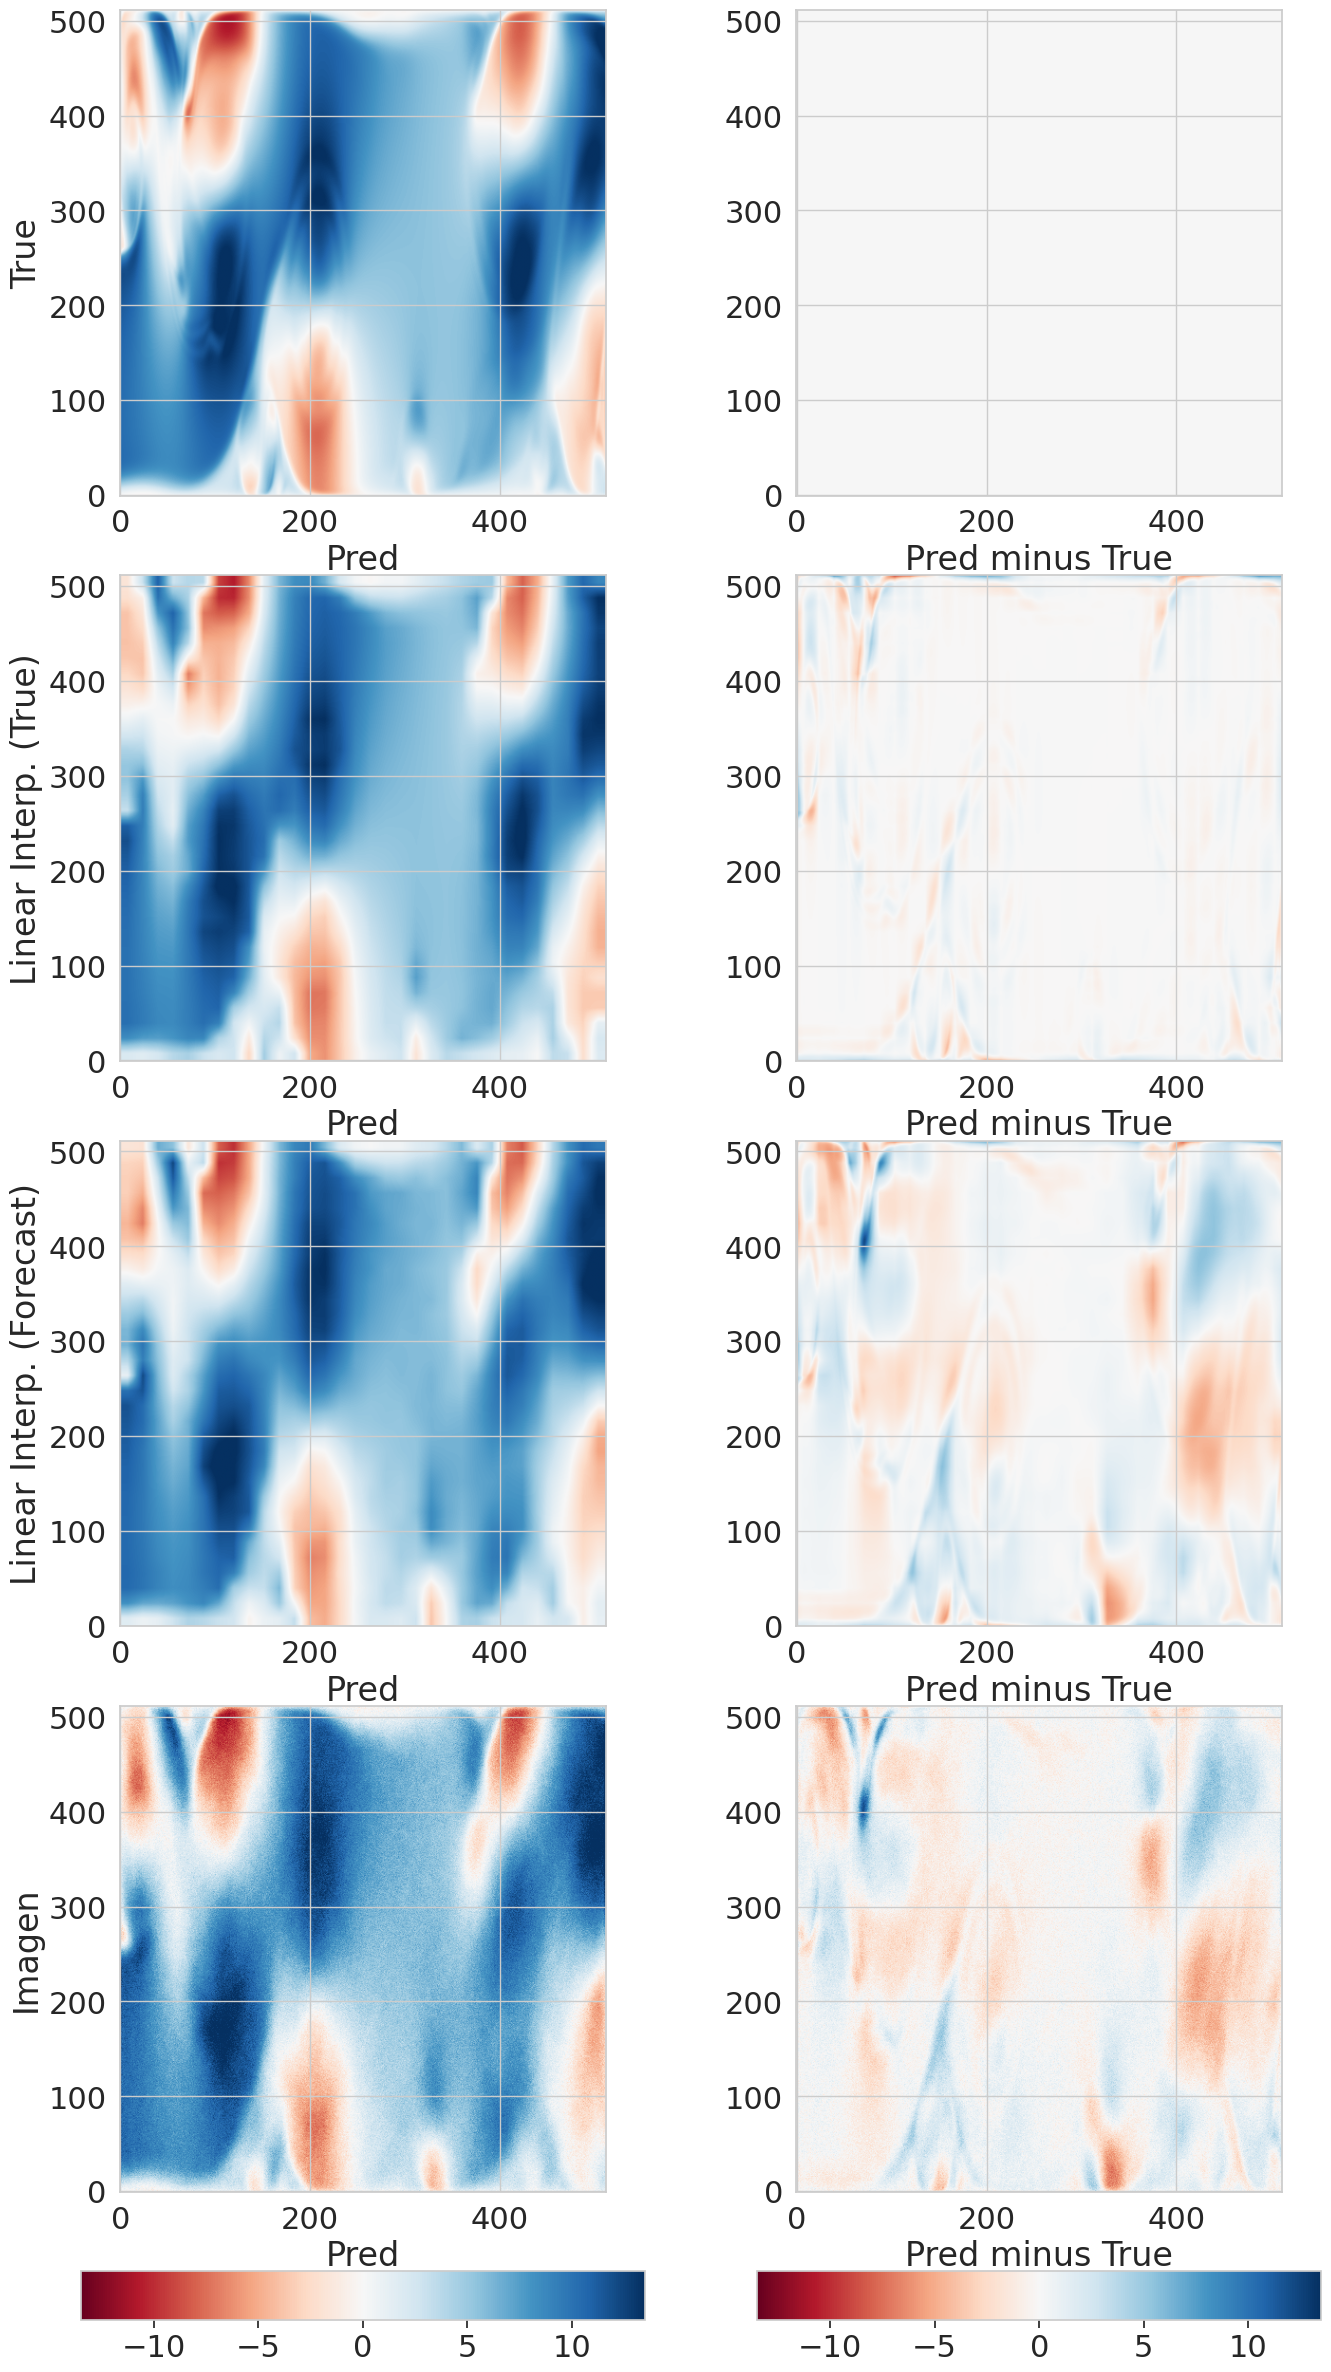

In [7]:
trajectory = 0
time_step = -1
component = 0

data_true = context[runs.filter(alt_id=TRUE_RUN)['key'][0]]['window_pred'][trajectory, time_step, component]
p = .01
v_abs_max = max(np.quantile(data_true, p), np.quantile(data_true, 1 - p))

plot_context = {
    k: context[k]['window_pred'][trajectory, time_step, component] for k in runs.get_column('key')
}
fig, axs = plt.subplots(figsize=(16, 6 + 6 * len(plot_context)), nrows=len(plot_context) + 1, ncols=2, height_ratios=[*([10] * len(plot_context)), 1])
for axs_row, (k, data) in zip(axs, plot_context.items()):
    im_out_pred = axs_row[0].imshow(data, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    run = runs.filter(key=k)
    axs_row[0].set_xlabel('Pred')
    axs_row[0].set_ylabel(run['label'][0])
    im_out_err = axs_row[1].imshow(data - data_true, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    axs_row[1].set_xlabel('Pred minus True')
fig.colorbar(im_out_pred, cax=axs[-1][0], orientation='horizontal')
fig.colorbar(im_out_err, cax=axs[-1][1], orientation='horizontal')

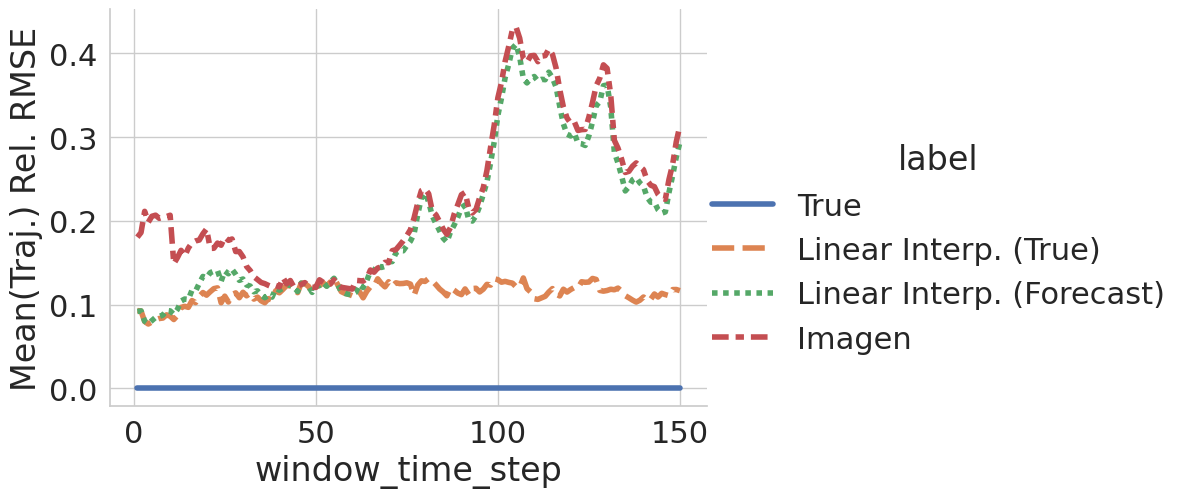

In [8]:
data_true = context[runs.filter(alt_id=TRUE_RUN)['key'][0]]['window_pred']
rel_rmses = {}
for k, v in context.items():
    data = v['window_pred']
    rmse = reduce(
        (data - data_true).square(),
        'trajectory time component width length -> trajectory time',
        'mean'
    ).sqrt()
    norm = reduce(
        data_true.square(),
        'trajectory time component width length -> trajectory time',
        'mean'
    ).sqrt()
    rel_rmses[k] = (rmse / norm).mean(0).numpy()
rel_rmses = pl.DataFrame(rel_rmses).with_columns(window_time_step=pl.int_range(1, pl.len()+1))
# print(rel_rmses)
plot_data = (
    rel_rmses
    .unpivot(index='window_time_step', variable_name='key', value_name='Mean(Traj.) Rel. RMSE')
    .join(runs, on='key')
)
# print(plot_data)
row_order = runs.sort('key').get_column('label')
plot_rmse = (
    sns.relplot(
        kind='line',
        data=plot_data,
        x='window_time_step',
        y='Mean(Traj.) Rel. RMSE',
        hue_order=row_order,
        style_order=row_order,
        hue='label',
        style='label',
        markers=data_true.shape[1] <= 100,
        linewidth=4,
        markersize=12,
        height=5.5,
        aspect=1.5,
    )
)